In [163]:
from qutip import tensor, sigmax, sigmay, sigmaz, basis, qeye, sigmap
import numpy as np
from weylchamber import canonical_gate, c1c2c3
from gulps.invariants import (
    mono_coordinates_to_CAN,
    mono_coordinates_to_makhlin,
    positive_canonical_to_monodromy_coordinate,
    recover_local_equivalence,
)
from qiskit.circuit.library import CXGate
from qiskit.quantum_info import Operator
from qiskit import QuantumCircuit

In [ ]:
h = (1 / np.sqrt(2)) * (sigmax() + sigmaz())

In [205]:
qc = QuantumCircuit(1)
qc.h(0)
qc.s(0)
qc.z(0)
qc.sdg(0)
qc.h(0)
# 1q euler decomposition
from qiskit.synthesis.one_qubit import OneQubitEulerDecomposer

qc = OneQubitEulerDecomposer("ZXZ")(Operator(qc))
qc.draw()

global phase: π/2
   ┌───────┐
q: ┤ Rx(π) ├
   └───────┘

In [184]:
# define RZ(theta=d) and RY(theta=e)
Zd = (-1j * np.pi * sigmaz()).expm()
Ze = (-1j * -np.pi * sigmay()).expm()
Zd @ sigmay() @ Ze

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 2.87948139e-32-2.35127499e-16j  1.22464680e-16-1.00000000e+00j]
 [ 1.22464680e-16+1.00000000e+00j -2.87948139e-32-2.35127499e-16j]]

In [226]:
a1, a2 = np.random.random() * np.pi, np.random.random() * np.pi
beta = np.random.random() * np.pi
d, e = np.random.random() * 2 * np.pi, np.random.random() * 2 * np.pi
# define RZ(theta=d) and RY(theta=e)
Zd = (-1j * d / 2 * sigmaz()).expm()
Ze = (-1j * e / 2 * sigmay()).expm()

T = canonical_gate(a1, a2, 0) @ tensor(Zd, Ze) @ canonical_gate(0, beta, 0)
T = T.full()
T_m = c1c2c3(T)
B = canonical_gate(*T_m).full()
print(np.array(T_m) * np.pi / 2)

[1.41336381 0.02709407 0.        ]


In [160]:
from qiskit.synthesis import TwoQubitWeylDecomposition

TwoQubitWeylDecomposition(B)

TwoQubitWeylDecomposition.from_bytes(
    # TwoQubitWeylDecomposition [specialization=General] (
    # 	global phase: 0
    # 	     ┌────────┐┌───────────────┐┌────────────────┐┌────────┐
    # 	q_0: ┤ Rz(-π) ├┤0              ├┤0               ├┤ Rz(-π) ├
    # 	     ├────────┤│  Rxx(-1.3976) ││  Ryy(-0.42315) │├────────┤
    # 	q_1: ┤ Rz(-π) ├┤1              ├┤1               ├┤ Rz(-π) ├
    # 	     └────────┘└───────────────┘└────────────────┘└────────┘
    # )
    b'k05VTVBZAQB2AHsnZGVzY3InOiAnPGMxNicsICdmb3J0cmFuX29yZGVyJzogRmFsc2UsICdzaGFw'
    b'ZSc6ICg0LCA0KSwgfSAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAg'
    b'ICAgICAgICAgICAgIAo3kkhlykbsPwAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
    b'AAAAAAAAAAAAAAAAAAGzKW9n9t0/AAAAAAAAAAAAAAAAAAAAABrVx5d9oeM/AAAAAAAAAAAAAAAA'
    b'AAAAAMIdEs1pRek/AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAMEdEs1p'
    b'Rek/GtXHl32h4z8AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAACzKW9n9t0/AAAAAAAA'
    b'AAAAAAAAAAAAAAAAAAAAAA

0.2000478613991965
1.0


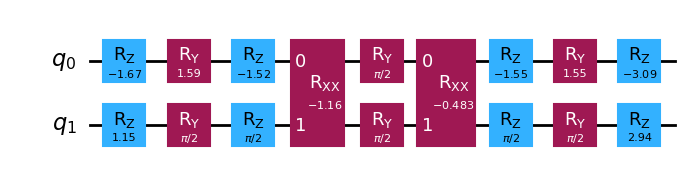

In [138]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import (
    CXGate,
    CZGate,
    UnitaryGate,
    XXPlusYYGate,
    RXXGate,
    RYYGate,
    RZZGate,
)
from qiskit.quantum_info import Operator, average_gate_fidelity

target_gate = Operator(T)
basis_gate = Operator(B)
print(average_gate_fidelity(target_gate, basis_gate))

k1, k2, k3, k4, gphase = recover_local_equivalence(target_gate, basis_gate)
qc = QuantumCircuit(2, global_phase=gphase)
qc.append(UnitaryGate(k1), [0])
qc.append(UnitaryGate(k2), [1])
qc.append(basis_gate, [0, 1])
qc.append(UnitaryGate(k3), [0])
qc.append(UnitaryGate(k4), [1])

from qiskit.transpiler.passes import Optimize1qGates
from qiskit.transpiler import PassManager

qc = transpile(qc, basis_gates=["rxx", "ry", "rz"])
print(average_gate_fidelity(target_gate, Operator(qc)))
qc.draw("mpl")

In [259]:
import sympy as sp
from sympy import I, cos, sin, sqrt, simplify
from sympy.physics.quantum import TensorProduct

# Pauli matrices
I2 = sp.eye(2)
X = sp.Matrix([[0, 1], [1, 0]])
Y = sp.Matrix([[0, -I], [I, 0]])
Z = sp.Matrix([[1, 0], [0, -1]])

# Two-qubit generators
XX = TensorProduct(X, X)
YY = TensorProduct(Y, Y)

# Symbols for parameters
a1, a2, d, e, beta = sp.symbols("a1 a2 d e beta", real=True)

# CAN gate: e^{-i (a1 XX + a2 YY)}
lam = sqrt(a1**2 + a2**2)
H = a1 * XX + a2 * YY
CAN_exp = cos(lam) * sp.eye(4) - I * sin(lam) * H / lam

# Local Z rotations: e^{-i d Z} ⊗ e^{-i e Z}
Z_d = cos(d) * I2 - I * sin(d) * Z
Z_e = cos(e) * I2 - I * sin(e) * Z
Z_local = TensorProduct(Z_d, Z_e)

# XX_beta: e^{-i beta XX}
XX_exp = cos(beta) * sp.eye(4) - I * sin(beta) * XX

# Total product U = CAN . Z_local . XX_beta
U = simplify(CAN_exp * Z_local * XX_exp)
U

Matrix([
[  ((-a1 + a2)*exp(I*d + I*e)*sin(beta)*sin(sqrt(a1**2 + a2**2)) + sqrt(a1**2 + a2**2)*(I*sin(d) - cos(d))*(I*sin(e) - cos(e))*cos(beta)*cos(sqrt(a1**2 + a2**2)))/sqrt(a1**2 + a2**2),                                                                                                                                                                                       0,                                                                                                                                                                                       0, -I*((a1 - a2)*exp(I*d + I*e)*sin(sqrt(a1**2 + a2**2))*cos(beta) + sqrt(a1**2 + a2**2)*(I*sin(d) - cos(d))*(I*sin(e) - cos(e))*sin(beta)*cos(sqrt(a1**2 + a2**2)))/sqrt(a1**2 + a2**2)],
[                                                                                                                                                                                    0,   ((a1 + a2)*(I*sin(e) - cos(e))*exp(I*d)*sin(beta)*sin(sqrt(a1**2 + 

In [ ]:
# Extract key matrix entries (1,1) and (3,3)
entry_11 = simplify(U[0, 0])
entry_33 = simplify(U[2, 2])

# Compute squared norms of these entries
norm_11 = simplify(sp.Abs(entry_11) ** 2)
norm_33 = simplify(sp.Abs(entry_33) ** 2)

print("Entry U[1,1] =", entry_11)
print("Entry U[3,3] =", entry_33)
print("Norm |U[1,1]|^2 =", norm_11)
print("Norm |U[3,3]|^2 =", norm_33)